### Imports and Setup

In [1]:
import os
from scipy.io import wavfile
import numpy as np
import torch
import torch.nn.functional as F
import librosa
import matplotlib.pyplot as plt
import pyproj as proj
import h5py

from whale_gunshot_localization import config
from whale_gunshot_localization.utils.experimental import L2Standardize, MultilaterationOpt, WAVReader, ClipAnalyzer, Localizer
from whale_gunshot_localization.models.tcn_archs import TCNRangeAndClassify
from whale_gunshot_localization.utils.transformations import to_spect, get_image_transform_range_classify

Some Setup For Global Variables

In [2]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")

# derive TOSSIT locations relative to the first from the lat/lons
TOSSIT_latlons = np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
pargs = proj.Proj(proj="aeqd", lat_0=TOSSIT_latlons[0, 0], lon_0=TOSSIT_latlons[0, 1], datum="WGS84", units="m")
xs, ys = pargs(TOSSIT_latlons[:,1], TOSSIT_latlons[:,0]) # np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
TOSSIT_locations = np.asarray([-ys, xs]).T

# get image transforms
# transform = get_image_transform_range_classify()['eval']
preprocessor = L2Standardize(np.load(config['dataset']['data_directory'] + '/mean_range_classification.npy', allow_pickle=True),
                             np.load(config['dataset']['data_directory'] + '/std_range_classification.npy', allow_pickle=True))

# root path to experimental data examples
ccb_data_root = os.path.join(*config['dataset']['ccb_data_directory'].split("/")[:-2],"single_examples")

# load model and weights
model = TCNRangeAndClassify(input_size=232,
                            num_channels=7*[368],
                            kernel_size=6,
                            dropout=0.2).to(device)
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'], config['models']['model_dir'], 'weights_best.pt'),
                       map_location=device)['model_state_dict']
model.load_state_dict(state_dict)
model.eval();

Using the GPU!


Load Experimental Example

In [56]:
idx = 58

# load
with h5py.File(os.path.join("/",ccb_data_root,f"gunshots_{idx}.h5"), "r") as f:
    inputs_short = f["/data"][:]
    sensors_short = f["/sensors"][:].squeeze()
    true_latlon_short = f["/location"][:].squeeze()

try:
    with h5py.File(os.path.join("/",ccb_data_root,f"gunshots_long_{idx}.h5"), "r") as f:
        inputs_long = f["/data"][:]
        sensors_long = f["/sensors"][:].squeeze()
        true_latlon_long = f["/location"][:].squeeze()
    assert (i == j for i, j in zip(true_latlon_short, true_latlon_long)), "True locations are different"
except:
    raise FileNotFoundError("Corresponding long file is not available")

### Helper Functions

In [57]:
def circle(r, a, b):
    """
    Produce points on a circle.
    
    Parameters
    ----------
    r : float
        radius of circle
    a : float
        x coordinate of circle center
    b : float
        y coordinate of circle center
        
    Returns
    -------
    (x, y) : Tuple[array-like, array-like]
        lists of x and y points on the circle perimeter
    """
    
    theta = np.linspace(0, 2*np.pi, 100)
    x = r*np.cos(theta) + a
    y = r*np.sin(theta) + b
    return x, y

def localize(r_p, sensors_idx, TOSSIT_locations):
    
    ML = MultilaterationOpt(method_thresh=float('inf'))
    # set geometry
    ML.set_map({
        'TOSSIT_locations' : TOSSIT_locations,
        'min_x' : config['scaling']['min_x'],
        'max_x' : config['scaling']['max_x'],
        'min_y' : config['scaling']['min_y'],
        'max_y' : config['scaling']['max_y'],
    })
        
    _, loc = ML.localize(r_p, sensors_idx)
            
    return loc

def sensor2idx(sensors):
    """
    Convert TOSSIT ID numbers to index in
    the list defined at config['TOSSIT']['ids'].
    
    Parameters
    ----------
    sensors : List[float] or List[int]
        list of sensor IDs
    
    Returns
    -------
    List[Int]
        list of sensor indices
    """
        
    return [config['TOSSIT']['ids'].index(str(int(s))) for s in sensors]

def preprocess_individual_examples(inputs, sensors, true_latlon):
    """
    Preprocess individual examples for processing
    
    
    """
    
    # get sensor indices
    sensor_indices = sensor2idx(sensors)

    # get position and sensor ranges
    xt, yt = pargs(true_latlon[1], true_latlon[0])
    yt = -yt
    location_m = np.asarray([[yt, xt]])
    ranges = np.sqrt(((TOSSIT_locations - location_m) ** 2).sum(axis=1))
    
    # preprocess
    inputs = preprocessor(inputs)

    return inputs, ranges, location_m

def scan_data(CA, inputs, sensors, true_latlon):
    
    # get sensor indices
    sensors_idx = sensor2idx(sensors)

    # get position and sensor ranges
    xt, yt = pargs(true_latlon[1], true_latlon[0])
    yt = -yt
    location_m = np.asarray([[yt, xt]])
    ranges = np.sqrt(((TOSSIT_locations - np.asarray([[yt, xt]])) ** 2).sum(axis=1))

    result = CA.process_clips(inputs)

    rp = [x[1] for x in result]
    spects = [x[0].squeeze() for x in result if len(x[1])]
    
    return rp, spects, location_m
    
def plot_range_regression(r_t, r_p):

    # get endpoints for identity line
    r_mm = (0, config['scaling']['max_r'] + 5000)
    
    plt.plot(r_t / 1000, r_p / 1000, 'bo', markersize=4)
    plt.plot([r_mm[0] / 1000, r_mm[1] / 1000], [r_mm[0] / 1000, r_mm[1] / 1000], 'r--', label="identity line")
    plt.grid()
    plt.xlabel("True Range [km]")
    plt.ylabel("Predicted Range [km]")
    plt.legend()
    plt.xlim(0, 20)
    plt.ylim(0, 20)
    
def plot_localization(rp, true_loc, est_loc, sensors=None, include_predictions=False, circles=False):

    # plot TOSSITs
    plt.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], 'kx', markersize=10, label="TOSSIT")

    # plot predicted and true location with range circles
    if include_predictions:
        for idx, r in enumerate(rp):
            if sensors is not None:
                idx = sensors[idx]
            if circles:
                x, y = circle(r, TOSSIT_locations[idx,1], TOSSIT_locations[idx,0])
                plt.plot(x, y, '-b')
    
    plt.plot(est_loc[1], est_loc[0], 'ro', label="Location Estimate", markersize=10)
    plt.plot(true_loc[1], true_loc[0], 'g^', label="True Location", markersize=10)

    # labels
    plt.gca().invert_yaxis()
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.legend()

### Manual Localization

Preprocess Data

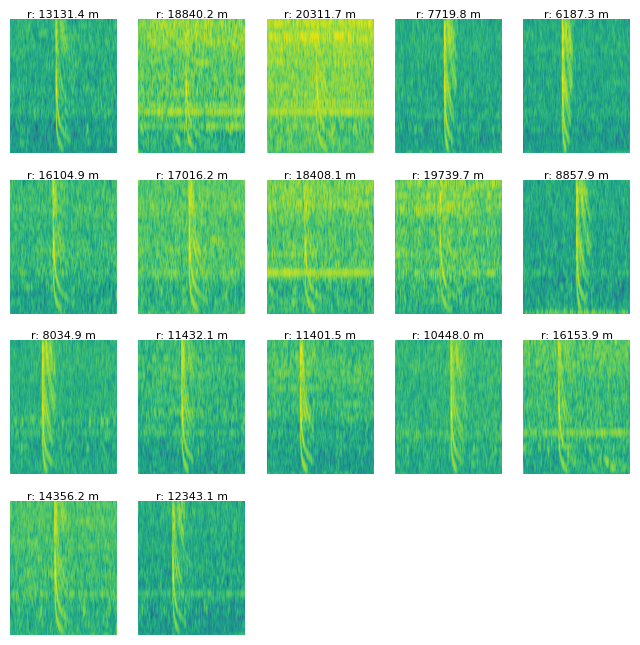

In [58]:
# preprocess the individual examples
inputs_short, ranges_short, true_location_m_short = preprocess_individual_examples(inputs_short, 
                                                                                   sensors_short, 
                                                                                   true_latlon_short)
# display data
rows = int(np.floor(np.sqrt(inputs_short.shape[0])));
columns = int(np.ceil(inputs_short.shape[0]/rows));
fig, axs = plt.subplots(rows,columns)
c = 0
for ax1 in axs:
    for ax2 in ax1:
        if c >= inputs_short.shape[0]:
            fig.delaxes(ax2)
        else:
            ax2.imshow(inputs_short[c,...], aspect='auto')
            ax2.axis('off')
            ax2.set_title(f"r: {np.around(ranges_short[c], 1)} m",fontsize=8, y=0.95)
        c += 1

Run The Network And Get Ranges

statistics
-------------------
MAE: 824.957 m
MAE All: 1198.062 m


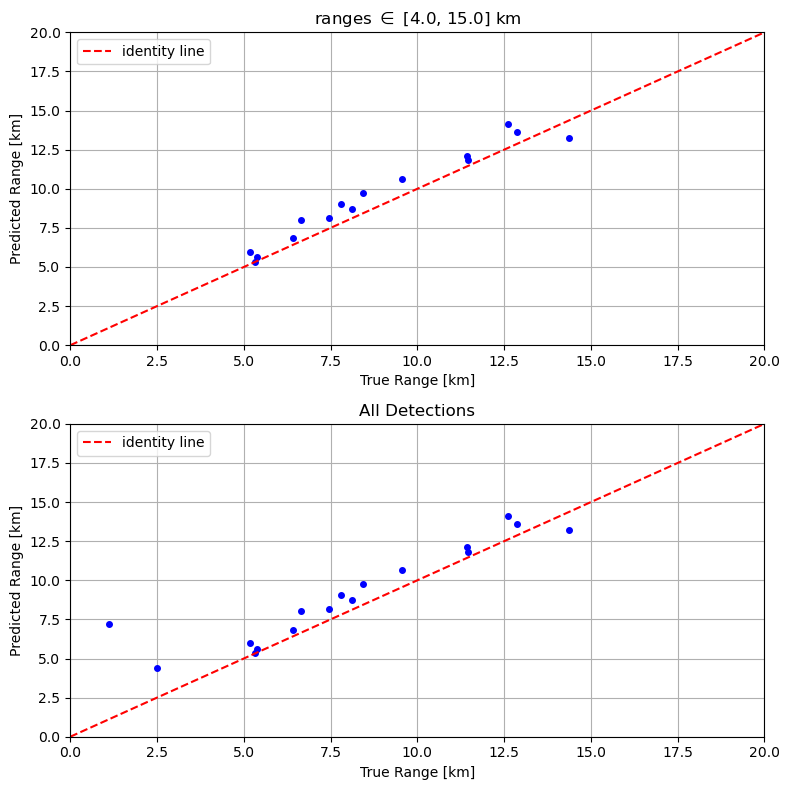

In [47]:
with torch.set_grad_enabled(False):
    inputs_short = inputs_short.to(device)
    outputs_short = model(inputs_short).to('cpu')

############################################
#   Calls With r <= r_max And r >= r_min
############################################
# get indices of detections and where 
# true ranges fall in synthetic range distribution
detections_idx = np.where((F.softmax(outputs_short[:,1:], dim=1)[:,1] >= 0.5) & (ranges_short >= config['scaling']['min_r']) & (ranges_short <= config['scaling']['max_r']))[0]

# get predicted ranges and their corresponding sensor indices
rp_short = (outputs_short[detections_idx,0] * config['scaling']['max_r']).numpy()
sensors_idx_short = np.asarray(sensor2idx(sensors_short[detections_idx]))

##################################
#           All Ranges
##################################
# get indices of detections and where 
# true ranges fall in synthetic range distribution
detections_idx_all = np.where((F.softmax(outputs_short[:,1:], dim=1)[:,1] >= 0.5))[0]

# get predicted ranges and their corresponding sensor indices
rp_short_all = (outputs_short[detections_idx_all,0] * config['scaling']['max_r']).numpy()
sensors_idx_short_all = np.asarray(sensor2idx(sensors_short[detections_idx_all]))

plt.subplot(2,1,1)
plt.title(f"ranges $\in$ [{config['scaling']['min_r'] / 1000}, {config['scaling']['max_r'] / 1000}] km")
plot_range_regression(ranges_short[detections_idx], rp_short)
plt.subplot(2,1,2)
plt.title("All Detections")
plot_range_regression(ranges_short[detections_idx_all], rp_short_all)
plt.tight_layout()
print("statistics")
print("-------------------")
print(f'MAE: {np.around(np.abs(rp_short - ranges_short[detections_idx]).mean(), 3)} m')
print(f'MAE All: {np.around(np.abs(rp_short_all - ranges_short[detections_idx_all]).mean(), 3)} m')

Manually Localize

In [49]:
loc_short = localize(rp_short, sensors_idx_short, TOSSIT_locations)
loc_short_all = localize(rp_short_all, sensors_idx_short_all, TOSSIT_locations)

statistics
-------------------
Error: 738.041 m
Error All: 1243.84 m


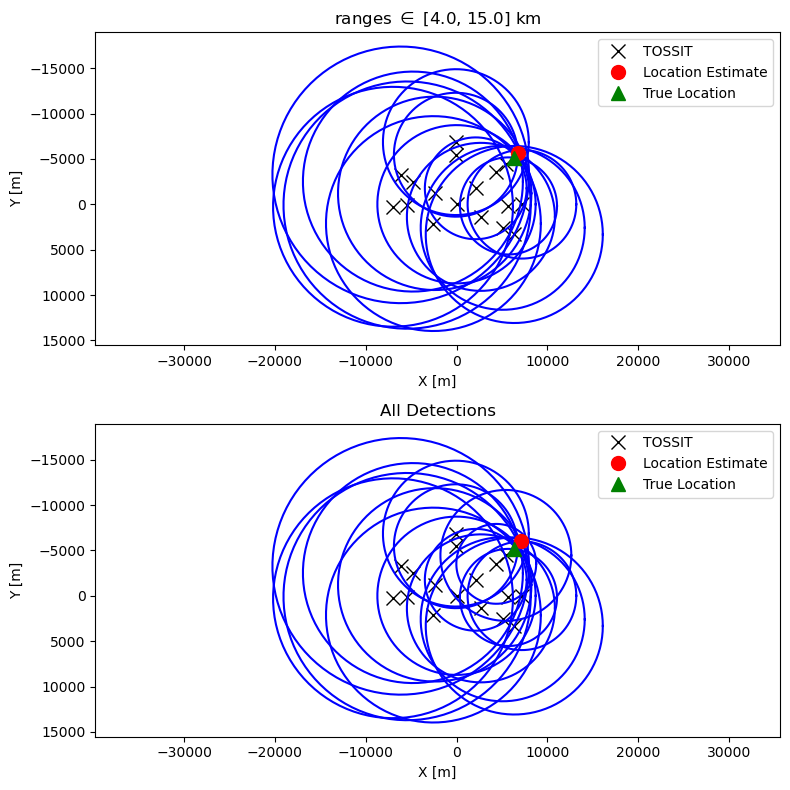

In [50]:
plt.subplot(2,1,1)
plot_localization(rp_short, true_location_m_short.squeeze(), loc_short, sensors=sensors_idx_short, include_predictions=True, circles=True)
plt.title(f"ranges $\in$ [{config['scaling']['min_r'] / 1000}, {config['scaling']['max_r'] / 1000}] km")
plt.axis('equal')
plt.subplot(2,1,2)
plot_localization(rp_short_all, true_location_m_short.squeeze(), loc_short_all, sensors=sensors_idx_short_all, include_predictions=True, circles=True)
plt.title("All Detections")
plt.axis('equal')
plt.tight_layout()

print("statistics")
print("-------------------")
print(f'Error: {np.around(np.sqrt(((loc_short - true_location_m_short.squeeze()) ** 2).sum()), 3)} m')
print(f'Error All: {np.around(np.sqrt(((loc_short_all - true_location_m_short.squeeze()) ** 2).sum()), 3)} m')

### Scan and Localize

Get Data Scanner

In [51]:
data_params = {'fs' : config['signal']['fs'],
               'T' : config['signal']['T'],}
preprocessor = L2Standardize(np.load(config['dataset']['data_directory'] + '/mean_range_classification.npy', allow_pickle=True),
                             np.load(config['dataset']['data_directory'] + '/std_range_classification.npy', allow_pickle=True))
CA = ClipAnalyzer(model, 
                  data_params, 
                  preprocessor,
                  device)

Scan Data For Calls

Text(0.5, 0.98, 'Detected Calls')

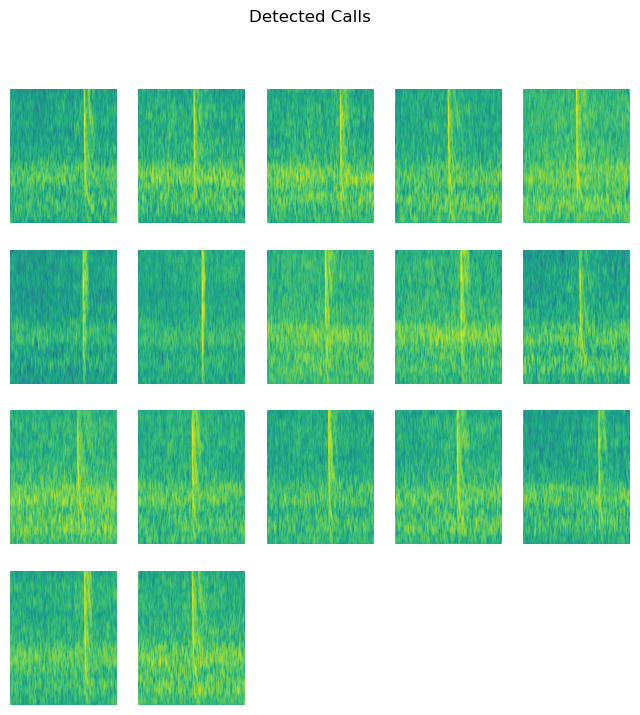

In [52]:
# scan long data intervals which contain the 
rp_long, spects_long, true_location_m_long = scan_data(CA, inputs_long, sensors_long, true_latlon_long)

rows = int(np.floor(np.sqrt(len(spects_long))));
columns = int(np.ceil(len(spects_long)/rows));
fig, axs = plt.subplots(rows,columns)
c = 0
for ax1 in axs:
    for ax2 in ax1:
        if c >= len(spects_long):
            fig.delaxes(ax2)
        else:
            ax2.imshow(spects_long[sensor2idx([sensors_long[c]])[0]].squeeze(), aspect='auto')
            ax2.axis('off')
        c += 1
fig.suptitle("Detected Calls")

Associate And Localize

In [53]:
L = Localizer(k=6, multilat=MultilaterationOpt(method_thresh=float('inf')), consistency_thresh=400, prune=False, TOSSIT_locations=TOSSIT_locations)

success = L.set_measurements(rp_long, adaptive=False)
assocs, loc = L.associate_and_localize(reduce_dups=False, last_step=True)

statistics
-------------------
Error Manual: 738.041 m
Error Automatic: 1023.723 m


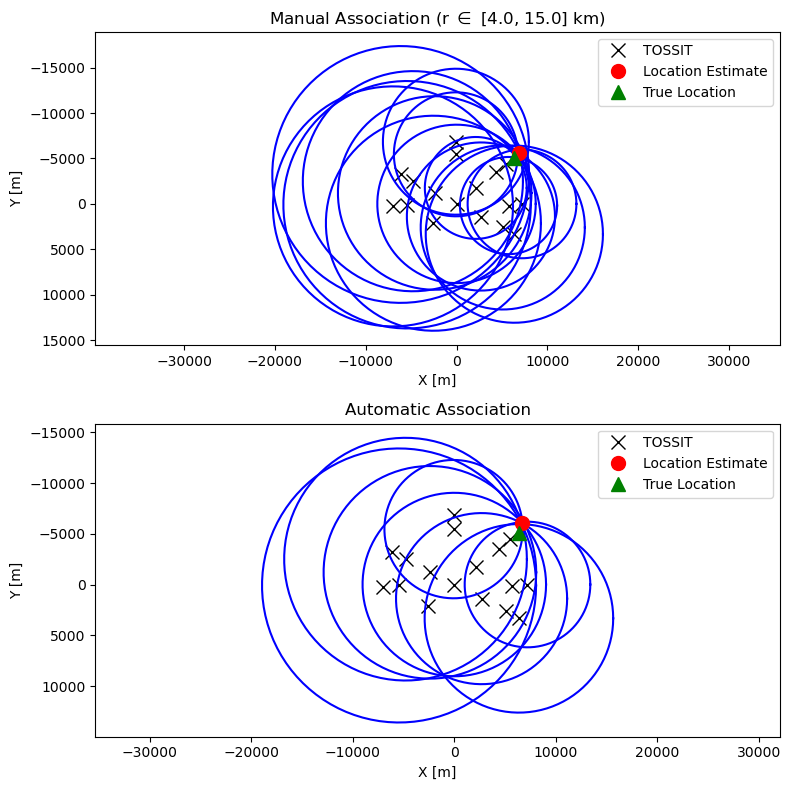

In [54]:
rp_linear = []
sensor_list = []
detected_spects = []
assocs_list = list(assocs[0])
for idx,i in enumerate(rp_long):
    for j in i:
        rp_linear.append(j)
        sensor_list.append(idx)
        
rp_final = []
sensor_final = []
spects_final = []
for idx, i in enumerate(rp_linear):
    if idx in assocs_list:
        rp_final.append(rp_linear[idx])
        sensor_final.append(sensor_list[idx])
        spects_final.append(spects_long[idx])

plt.subplot(2,1,1)
plot_localization(rp_short, true_location_m_short.squeeze(), loc_short, sensors=sensors_idx_short, include_predictions=True, circles=True)
plt.title(f"Manual Association (r $\in$ [{config['scaling']['min_r'] / 1000}, {config['scaling']['max_r'] / 1000}] km)")
plt.axis('equal')
plt.subplot(2,1,2)
plot_localization(rp_final, true_location_m_long.squeeze(), loc.squeeze(), sensors=sensor_final ,include_predictions=True, circles=True)
plt.title("Automatic Association")
plt.axis('equal')
plt.tight_layout()
print("statistics")
print("-------------------")
print(f'Error Manual: {np.around(np.sqrt(((loc_short - true_location_m_short.squeeze()) ** 2).sum()), 3)} m')
print(f'Error Automatic: {np.around(np.sqrt(((loc - true_location_m_long) ** 2).sum()), 3)} m')

Text(0.5, 0.98, 'Utilized Calls')

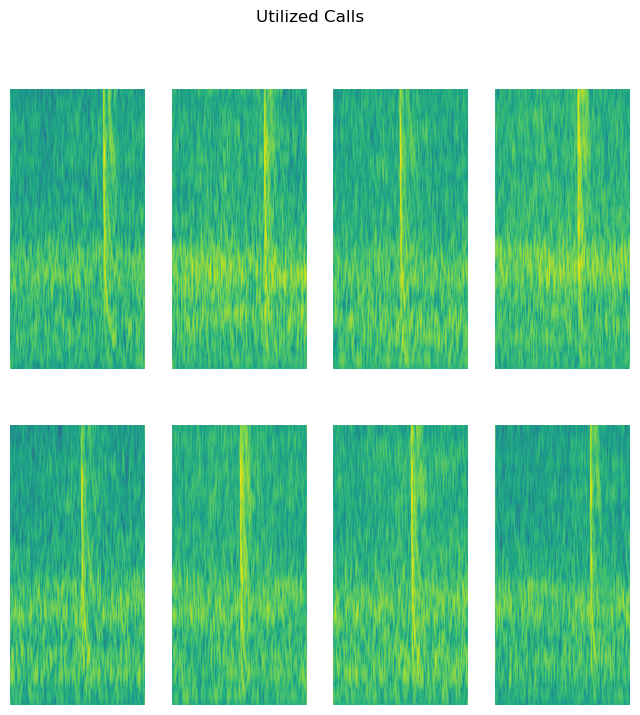

In [55]:
rows = int(np.floor(np.sqrt(len(spects_final))));
columns = int(np.ceil(len(spects_final)/rows));
fig, axs = plt.subplots(rows,columns)
c = 0
for ax1 in axs:
    for ax2 in ax1:
        if c >= len(spects_final):
            fig.delaxes(ax2)
        else:
            ax2.imshow(spects_final[c].squeeze(), aspect='auto')
            ax2.axis('off')
            # ax2.set_title(f"r: {np.around(ranges[c], 1)} m",fontsize=8, y=0.95)
        c += 1
fig.suptitle("Utilized Calls")